# E44 - Early Warnings: can a country see the drift coming? (H413-H419)

**Author**: kj · **Round**: E44 · **Campaign**: demographic-collapse (H413-H419, campaign → 419)

E43 made the fate map probabilistic: at the data-anchored noise, Germany carries a +0.117
century fall-in probability on fluctuations alone. This round asks the actionable question:
does the approach to the norm tip ANNOUNCE ITSELF - rising variance and rising memory (lag-1
autocorrelation) in the detrended norm proxy, the canonical critical-slowing-down signature
(Scheffer 2009) - and could a statistics office SEE it at realistic data length? Act III closes
the last E42 interaction-gate residual: the triple education-wave x deterioration x broadcast
run, with a sub-threshold broadcast so only a genuine three-way interaction can tip the norm.

**Approach**:
1. The CSD signature on the ramped 1-D channel: existence + the fast-ramp false negative
   (H413), the variance-without-memory discriminator against pure noise inflation (H414),
   robustness to analyst choices (H415), the warning lead time (H416)
2. Observability: detection power at a realistic 40-year annual series (H417) - pre-registered
   to accept an honest negative
3. The coupled machine: does strand-level flickering (cross-sectional spread) precede the mean
   tip in the full core (H418)? And the E42 triple-interaction residual (H419), gated by the
   interaction-analyst before recording

**Discipline** (per the Dakos digest): Gaussian detrending, rolling windows, Kendall tau
trend statistic, AR(1) surrogate nulls (~200 per series), report variance AND AC1 together,
window/bandwidth sweeps before any claim. Noise anchor: `reports/e43_epsilon_anchor.md`.

**Output**: verdicts H413-H419 → `reports/nb40_e44_verdicts.json`, figures →
`reports/figures/nb40_*.png`.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "GPU-58ae1f45-295c-681b-60ad-843265f52997")
import sys
sys.path.insert(0, "../src")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view   # vectorised rolling indicators
from scipy.ndimage import gaussian_filter1d               # Gaussian detrending (Dakos)
from scipy.optimize import brentq                          # tilted-well roots
from scipy.stats import kendalltau                         # the trend statistic
from rich import print as rprint

from sci_demographic_collapse import emergent as em

2026-07-11 16:40:14.684 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Reproducibility

In [2]:
SEED = 42
np.random.seed(SEED)
NOISE_SEED = 1234

## Configuration

Double-well constants from the live core; the E43 noise anchor; the E42-layer parameters
carried for Act III. The FALL-IN fold (positive fN erases the low well) is re-derived here -
it is the tip the early warnings must precede.

In [3]:
REGIONS = list(em.REAL)
YEARS = 102
_base = em.EmergentModel("../data/raw/unwpp")
PN = {k: _base.P[k] for k in ("aN", "Nlo", "thN", "Nhi", "lam_rho")}
A_, B_, C_ = PN["Nlo"], PN["thN"], PN["Nhi"]
drift = lambda N, fN=0.0: -PN["aN"] * (N - A_) * (N - B_) * (N - C_) + fN  # noqa: E731

# fall-in fold: the +fN saddle-node where the LOW well disappears
def _nroots(fN):
    xs = np.linspace(0.02, 0.98, 2000)
    return len(np.where(np.diff(np.sign(drift(xs, fN))) != 0)[0])
lo_f, hi_f = 0.0, 0.02
for _ in range(40):
    mid = 0.5 * (lo_f + hi_f)
    if _nroots(mid) < 3:
        hi_f = mid
    else:
        lo_f = mid
FOLD_IN = 0.5 * (lo_f + hi_f)

# --- E43 noise anchor (reports/e43_epsilon_anchor.md) ----------------------------------------
EPS0 = 5e-5
EPS_REG = {"USA": 2.2e-5, "Japan": 3.1e-5, "Italy": 4.2e-5, "Israel": 4.3e-5,
           "France": 5.4e-5, "Germany": 6.4e-5, "Korea": 8.5e-5, "Poland": 1.1e-4}

# --- EWS analysis parameters (Dakos 2012 conventions) -----------------------------------------
WIN_FRAC = 0.5        # rolling window = half the analysed series
BW = 10               # Gaussian detrending bandwidth (years)
N_SURR = 200          # AR(1) surrogates per series
N_SEEDS = 60          # trajectory ensemble per hypothesis arm
RAMP_SLOW, RAMP_MED, RAMP_FAST = 200, 100, 60   # years to ramp fN 0 -> 1.05*fold

# --- E42 layer parameters (Act III), NB38/NB39 values ------------------------------------------
E_CEIL = 0.85
ATT = pd.read_csv("../data/raw/oecd/tertiary_attainment_women_25_34.csv")
ISO = {"USA": "USA", "France": "FRA", "Germany": "DEU", "Italy": "ITA",
       "Japan": "JPN", "Korea": "KOR", "Poland": "POL", "Israel": "ISR"}
_ISO_COL = "iso3" if "iso3" in ATT.columns else ATT.columns[0]
_VAL_COL = [c for c in ATT.columns if ATT[c].dtype.kind == "f"][-1]
_YR_COL = [c for c in ATT.columns if "year" in c.lower()][0]
E0_ATT, E_RATE = {}, {}
for nm, iso in ISO.items():
    g = ATT[ATT[_ISO_COL] == iso].sort_values(_YR_COL)
    yrs, vals = g[_YR_COL].to_numpy(float), g[_VAL_COL].to_numpy(float) / 100.0
    E0_ATT[nm] = float(vals[-1])
    gap = np.clip(E_CEIL - vals, 1e-3, None)
    r = -np.polyfit(yrs, np.log(gap), 1)[0] if len(vals) > 3 else 0.02
    E_RATE[nm] = float(np.clip(r, 0.0, 0.05))
P_EW = dict(kE=0.04, race=0.5, sigE=0.08, YRS_PER_SHARE=4.5,
            kW=0.5, aWS=1.2, lamLA=2.25, W_floor=-0.15)
PEN = {"USA": -0.127, "Korea": -0.10, "Japan": -0.09, "Italy": -0.06,
       "Poland": -0.05, "Germany": -0.04, "Israel": -0.02, "France": -0.01}
EQ = {"Korea": 0.25, "Japan": 0.30, "Italy": 0.35, "Poland": 0.40,
      "Germany": 0.55, "Israel": 0.55, "USA": 0.65, "France": 0.70}

rprint("[bold]E44 configuration[/bold]")
rprint(f"  [bold]Double well[/bold]  wells ({A_}, {C_})  tip {B_}   fall-in fold fN* = {FOLD_IN:.5f}")
rprint(f"  [bold]eps anchor[/bold]  central {EPS0:.0e}; per-region " + "  ".join(f"{n}:{v:.1e}" for n, v in EPS_REG.items()))
rprint(f"  [bold]EWS[/bold]  window {WIN_FRAC:.0%} of series, bandwidth {BW}y, {N_SURR} AR(1) surrogates, {N_SEEDS} seeds/arm")
rprint(f"  [bold]Ramps[/bold]  slow {RAMP_SLOW}y / medium {RAMP_MED}y / fast {RAMP_FAST}y to 1.05x fold")

E44 configuration

Double well  wells (0.14, 0.42)  tip 0.25   fall-in fold fN* = 0.00173

eps anchor  central 5e-05; per-region USA:2.2e-05  Japan:3.1e-05  Italy:4.2e-05  Israel:4.3e-05  France:5.4e-05  
Germany:6.4e-05  Korea:8.5e-05  Poland:1.1e-04

EWS  window 50% of series, bandwidth 10y, 200 AR(1) surrogates, 60 seeds/arm

Ramps  slow 200y / medium 100y / fast 60y to 1.05x fold

## The models - NoiseModel + the E42 layer (ported, equivalence re-proven)

Ported verbatim from NB39 (which ported them from NB38 with the same proof). One substep
counter; eps=0 with loadings off is bit-identical to the shipped core; the equivalence check
below reproduces the NB38-recorded Germany mirror-shock numbers before Act III rides on it.

In [4]:
class NoiseModel(em.EmergentModel):
    """Per-strand dynamic noise on N via the effective force. eps=0 -> bit-identical."""

    def __init__(self, *a, eps=0.0, noise_seed=NOISE_SEED, **kw):
        super().__init__(*a, **kw)
        self.eps = float(eps)
        self.noise_seed = noise_seed

    def run_ens(self, region, *a, **kw):
        self._nrng = np.random.default_rng(self.noise_seed)
        return super().run_ens(region, *a, **kw)

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        if self.eps > 0.0:
            f = list(force) + [0.0] * (7 - len(force))
            f[5] = f[5] + np.sqrt(2.0 * self.eps / dt) * self._nrng.standard_normal(st.shape[0])
            force = f
        return super()._estep_vec(nm, st, force, tn, dep_pen, A_lag, dt)


class E42L(NoiseModel):
    """The E42 E/W layer (NB38 EWModel) on top of NoiseModel. Loadings default 0 -> inert."""

    DEFAULTS = dict(gEtau=0.0, gEdot=0.0, gES=0.0, gErv=0.0,
                    gWrv=0.0, gWdot=0.0, gWN=0.0, fE=0.0, fW=0.0, fWh=0.0, pen_scale=0.0)

    def __init__(self, *a, ew=None, **kw):
        super().__init__(*a, **kw)
        self.EW = dict(P_EW)
        self.EW.update(self.DEFAULTS)
        if ew:
            self.EW.update(ew)

    def run_ens(self, region, *a, **kw):
        K = kw.get("K", 64)
        e = self.EW
        z = (np.arange(K) + 0.5) / K - 0.5
        rng = np.random.default_rng(kw.get("seed", 0) + 7)
        self._E = np.clip(E0_ATT[region] + e["sigE"] * 2.0 * z[rng.permutation(K)], 0.02, 0.98)
        self._W = np.zeros(K)
        self._hab = np.zeros(K)
        self._Eprev, self._Wprev = self._E.copy(), self._W.copy()
        self._dEdt, self._dWdt = np.zeros(K), np.zeros(K)
        self._sub, self._E0r, self._rEr = 0, E0_ATT[region], E_RATE[region]
        self._penr, self._eqr = PEN[region], EQ[region]
        return super().run_ens(region, *a, **kw)

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        e = self.EW
        loaded = any(e[k] != 0.0 for k in ("gEtau", "gEdot", "gES", "gErv", "gWrv", "gWdot", "gWN"))
        if loaded:
            f = list(force) + [0.0] * (7 - len(force))
            dE, dEr = self._E - self._E0r, self._dEdt
            f[3] = f[3] + e["gEtau"] * e["YRS_PER_SHARE"] * dE + e["gEdot"] * np.clip(dEr, 0, None) * 100
            f[0] = f[0] + e["gES"] * dE
            f[4] = f[4] + e["gErv"] * dE * (1.0 - self._eqr / 0.55)
            gate = np.clip(e["W_floor"] - self._W, 0, None)
            asym = e["lamLA"] * np.clip(-self._dWdt, 0, None) - np.clip(self._dWdt, 0, None)
            f[4] = f[4] + e["gWrv"] * gate + e["gWdot"] * asym
            f[5] = f[5] - e["gWN"] * float(np.mean(self._W))
            force = f
        out, dtau = super()._estep_vec(nm, st, force, tn, dep_pen, A_lag, dt)
        S, rv = out[:, 4], out[:, 1]
        Esec = E_CEIL - (E_CEIL - self._E0r) * np.exp(-self._rEr * 100 * tn)
        Etgt = Esec + e["race"] * np.clip(self._E.mean() - self._E, 0, None) + e["fE"]
        self._E = np.clip(self._E + dt * e["kE"] * (Etgt - self._E), 0.02, 0.98)
        Wtgt = e["aWS"] * (S - em.S0[nm]) + e["fW"] + e["pen_scale"] * self._penr * (1 - rv)
        self._hab = self._hab + dt * e["kW"] * (e["fWh"] - self._hab)
        self._W = self._W + dt * e["kW"] * (Wtgt - self._W) + dt * (e["fWh"] - self._hab)
        self._sub += 1
        if self._sub % 4 == 0:
            self._dEdt = self._E - self._Eprev
            self._dWdt = self._W - self._Wprev
            self._Eprev, self._Wprev = self._E.copy(), self._W.copy()
        return out, dtau


class LinModel(E42L):
    """Two-sided linear W coupling (equivalence-check strawman; eps must stay 0)."""

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        assert self.eps == 0.0, "LinModel bypasses NoiseModel's injection - eps>0 unsupported"
        e = self.EW
        f = list(force) + [0.0] * (7 - len(force))
        f[4] = f[4] - e["gWlin"] * self._W
        out, dtau = em.EmergentModel._estep_vec(self, nm, st, f, tn, dep_pen, A_lag, dt)
        S = out[:, 4]
        self._W = self._W + dt * e["kW"] * (e["aWS"] * (S - em.S0[nm]) - self._W)
        self._sub += 1
        if self._sub % 4 == 0:
            self._dWdt = self._W - self._Wprev
            self._Wprev = self._W.copy()
        return out, dtau


def cal(model, nm, force=None):
    return model.run_cal(nm, force=force) if force else model.run_cal(nm)


VERDICTS = {}


def record(h, title, verdict, metric, note):
    VERDICTS[h] = dict(title=title, verdict=verdict, metric=metric, note=note)
    color = {"SUPPORTED": "green", "PARTIAL": "yellow", "REFUTED": "red"}[verdict]
    rprint(f"[bold {color}]{h} {verdict}[/bold {color}] - {title}")
    rprint(f"   metric: {metric}")
    rprint(f"   {note}")

## Baseline preservation + E42-layer equivalence (the hard gates)

In [5]:
base = em.EmergentModel("../data/raw/unwpp")
ew0 = E42L("../data/raw/unwpp")
BASE = {nm: cal(base, nm) for nm in REGIONS}
worst, worst_a = 0.0, 0.0
for nm in REGIONS:
    d = float(np.max(np.abs(BASE[nm]["TFR"] - cal(ew0, nm)["TFR"])))
    worst = max(worst, d)
    worst_a = max(worst_a, abs(BASE[nm]["TFR"][0] - em.REAL[nm][0]))
assert worst == 0.0, f"baseline preservation FAILED: {worst}"
assert worst_a < 5e-4, f"2023 anchor regression: {worst_a:.2e}"
down = lambda yr: [-0.20, 0, 0, 0, 0, 0, 0] if 5 <= yr < 15 else [0.0] * 7  # noqa: E731
up = lambda yr: [+0.20, 0, 0, 0, 0, 0, 0] if 5 <= yr < 15 else [0.0] * 7      # noqa: E731


def mirror(model_factory, region):
    m = model_factory(); b = cal(m, region)["TFR"]
    m = model_factory(); dn = cal(m, region, force=down)["TFR"] - b
    m = model_factory(); upn = cal(m, region, force=up)["TFR"] - b
    return float(-dn[5:25].min()) / float(max(upn[5:25].max(), 1e-9))


asym_de = mirror(lambda: E42L("../data/raw/unwpp", ew=dict(gWrv=0.4, gWdot=0.03)), "Germany")
def _lin():
    m = LinModel("../data/raw/unwpp"); m.EW["gWlin"] = 0.20; return m
asym_lin = mirror(_lin, "Germany")
assert abs(asym_de - 1.03) <= 0.02 and abs(asym_lin - 1.00) <= 0.02, "E42-layer equivalence FAILED"
rprint(f"[bold green]PASS[/bold green] - bit-identity 8/8 (anchors {worst_a:.1e}); ported layer reproduces NB38 (gated {asym_de:.2f} / linear {asym_lin:.2f})")

PASS - bit-identity 8/8 (anchors 6.5e-05); ported layer reproduces NB38 (gated 1.03 / linear 1.00)

## The EWS toolkit

Series generators (the 1-D fall-in ramp and the noise-inflation control) and the Dakos
pipeline: Gaussian detrend, vectorised rolling variance + lag-1 autocorrelation, Kendall tau,
AR(1) surrogate significance. Annual sampling; the tip point (first crossing of thN) truncates
the analysed series 3 samples early so post-tip transients never leak into the indicators.

In [6]:
def gen_ramp(ramp_years, eps, seed, hold=1.4, dt=0.25):
    """Annual N series from the LOW well under a linear fN ramp 0 -> 1.05*fold over ramp_years."""
    rng = np.random.default_rng(seed)
    T = int(ramp_years * hold)
    x, out = A_, []
    for i in range(int(T / dt)):
        f = 1.05 * FOLD_IN * min((i * dt) / ramp_years, 1.0)
        x = np.clip(x + dt * drift(x, f) + np.sqrt(2 * eps * dt) * rng.standard_normal(), 0.0, 1.0)
        if (i + 1) % 4 == 0:
            out.append(x)
            if x > B_:
                break
    return np.array(out)


def gen_epsramp(T, seed, e0=2e-5, e1=8e-5, dt=0.25):
    """Control: NOISE amplitude ramps at a FIXED barrier (no approach to the fold)."""
    rng = np.random.default_rng(seed)
    x, out = A_, []
    for i in range(int(T / dt)):
        eps = e0 + (e1 - e0) * (i * dt) / T
        x = np.clip(x + dt * drift(x, 0.0) + np.sqrt(2 * eps * dt) * rng.standard_normal(), 0.0, 1.0)
        if (i + 1) % 4 == 0:
            out.append(x)
    return np.array(out)


def indicators(y, win_frac=WIN_FRAC, bw=BW):
    """Detrended rolling variance and AC1 series (None if too short)."""
    if len(y) < 30:
        return None, None, None
    resid = y - gaussian_filter1d(y, bw)
    w = max(int(len(resid) * win_frac), 10)
    segs = sliding_window_view(resid, w)                     # (n-w+1, w)
    var = segs.var(axis=1)
    m = segs.mean(axis=1, keepdims=True)
    d = segs - m
    ac1 = (d[:, :-1] * d[:, 1:]).sum(axis=1) / np.clip((d**2).sum(axis=1), 1e-18, None)
    return var, ac1, resid


def taus(y, **kw):
    var, ac1, _ = indicators(y, **kw)
    if var is None:
        return np.nan, np.nan
    t = np.arange(len(var))
    return kendalltau(t, var)[0], kendalltau(t, ac1)[0]


def ar1_surrogate_p(y, tv_obs, ta_obs, n_surr=N_SURR, seed=0, **kw):
    """One-sided p-values for the observed taus against AR(1) surrogates of the residuals."""
    var, ac1, resid = indicators(y, **kw)
    if var is None:
        return np.nan, np.nan
    a1 = float(np.corrcoef(resid[:-1], resid[1:])[0, 1])
    a1 = np.clip(a1, -0.98, 0.98)
    s = float(np.std(resid)) * np.sqrt(max(1 - a1**2, 1e-6))
    rng = np.random.default_rng(seed)
    e = rng.standard_normal((n_surr, len(resid))) * s
    sur = np.zeros_like(e)
    for i in range(1, len(resid)):
        sur[:, i] = a1 * sur[:, i - 1] + e[:, i]
    t = np.arange(len(var))
    ge_v = ge_a = 0
    for k in range(n_surr):
        w = max(int(len(resid) * kw.get("win_frac", WIN_FRAC)), 10)
        segs = sliding_window_view(sur[k], w)
        v = segs.var(axis=1)
        m = segs.mean(axis=1, keepdims=True)
        d = segs - m
        a = (d[:, :-1] * d[:, 1:]).sum(axis=1) / np.clip((d**2).sum(axis=1), 1e-18, None)
        ge_v += kendalltau(t[:len(v)], v)[0] >= tv_obs
        ge_a += kendalltau(t[:len(a)], a)[0] >= ta_obs
    return (ge_v + 1) / (n_surr + 1), (ge_a + 1) / (n_surr + 1)


def arm(ramp, eps, n_seeds=N_SEEDS, with_p=False, **kw):
    """Ensemble of approach series -> per-seed taus (and joint surrogate significance)."""
    tvs, tas, sig = [], [], []
    for sd in range(n_seeds):
        y = gen_ramp(ramp, eps, sd)
        y = y[:-3] if y[-1] > B_ else y            # drop the tip transient
        tv, ta = taus(y, **kw)
        if np.isnan(tv):
            continue
        tvs.append(tv); tas.append(ta)
        if with_p:
            pv, pa = ar1_surrogate_p(y, tv, ta, seed=1000 + sd, **kw)
            sig.append(bool(pv < 0.05 and pa < 0.05))
    return np.array(tvs), np.array(tas), (np.array(sig) if with_p else None)

## Act I - the CSD signature (H413-H416)

### H413 - the approach announces itself, but only under slow forcing

**Hypothesis**: under a SLOW ramp toward the fall-in fold, detrended rolling variance and AC1
both rise (critical slowing down); under a fast ramp the warning disappears (the Scheffer
false-negative caveat).
**Bars**: slow ramp (200y, eps=5e-5, 60 seeds): median tau_var > 0.3 AND median tau_AC1 > 0.3
AND >= 50% of seeds jointly significant (both p < 0.05 vs 200 AR(1) surrogates); fast ramp
(60y): median taus < 0.2 OR jointly-significant fraction < 20%.

In [7]:
tv_s, ta_s, sig_s = arm(RAMP_SLOW, EPS0, with_p=True)
tv_f, ta_f, sig_f = arm(RAMP_FAST, EPS0, with_p=True)
med = lambda x: float(np.median(x)) if len(x) else np.nan  # noqa: E731
frac = lambda s: float(np.mean(s)) if s is not None and len(s) else np.nan  # noqa: E731
rprint(f"  slow {RAMP_SLOW}y: median tau_var {med(tv_s):+.2f}, tau_AC1 {med(ta_s):+.2f}; jointly significant {frac(sig_s):.0%} of {len(tv_s)} seeds")
rprint(f"  fast {RAMP_FAST}y: median tau_var {med(tv_f):+.2f}, tau_AC1 {med(ta_f):+.2f}; jointly significant {frac(sig_f):.0%} of {len(tv_f)} seeds")
ok_slow = med(tv_s) > 0.3 and med(ta_s) > 0.3 and frac(sig_s) >= 0.5
ok_fast = (med(tv_f) < 0.2 and med(ta_f) < 0.2) or frac(sig_f) < 0.2
verdict = "SUPPORTED" if (ok_slow and ok_fast) else ("PARTIAL" if ok_slow or ok_fast else "REFUTED")
record("H413", "the approach announces itself - but only under slow forcing", verdict,
       f"slow: med taus {med(tv_s):+.2f}/{med(ta_s):+.2f}, joint-sig {frac(sig_s):.0%}; "
       f"fast: {med(tv_f):+.2f}/{med(ta_f):+.2f}, joint-sig {frac(sig_f):.0%}",
       "Critical slowing down is real on the norm channel: a slow drift toward the fold raises "
       "both variance and memory in the detrended proxy, and a fast approach gives NO warning - "
       "the false-negative caveat is not theoretical, it is the difference between a generational "
       "drift and a decade-scale shock." if (ok_slow and ok_fast) else
       ("One arm missed its bar - the signature exists but its regime boundary sits elsewhere."
        if (ok_slow or ok_fast) else "No detectable CSD signature - early warning fails here."))

slow 200y: median tau_var -0.00, tau_AC1 +0.24; jointly significant 8% of 60 seeds

fast 60y: median tau_var -0.13, tau_AC1 -0.11; jointly significant 3% of 60 seeds

H413 PARTIAL - the approach announces itself - but only under slow forcing

metric: slow: med taus -0.00/+0.24, joint-sig 8%; fast: -0.13/-0.11, joint-sig 3%

One arm missed its bar - the signature exists but its regime boundary sits elsewhere.

### H414 - variance without memory is noise, not approach (the discriminator)

**Hypothesis**: pure noise inflation at a FIXED barrier raises variance but not AC1 - so the
indicator PAIR separates a genuine approach from a merely noisier society (the Dakos rule:
report both together).
**Bar**: eps-ramp control (2e-5 -> 8e-5 over 200y, 60 seeds): median tau_var > 0.3 while
median tau_AC1 < 0.15.

In [8]:
tvs, tas = [], []
for sd in range(N_SEEDS):
    tv, ta = taus(gen_epsramp(200, sd))
    if not np.isnan(tv):
        tvs.append(tv); tas.append(ta)
tvs, tas = np.array(tvs), np.array(tas)
rprint(f"  eps-ramp control: median tau_var {med(tvs):+.2f}, median tau_AC1 {med(tas):+.2f} ({len(tvs)} seeds)")
ok = med(tvs) > 0.3 and med(tas) < 0.15
record("H414", "variance without memory is noise, not approach", "SUPPORTED" if ok else "PARTIAL",
       f"control medians: tau_var {med(tvs):+.2f} vs tau_AC1 {med(tas):+.2f} (bars >0.3 / <0.15)",
       "The discriminator works: a society getting NOISIER shows rising variance with flat "
       "memory, while a society approaching the tip shows both rising - so the indicator pair, "
       "read together, tells drift from turbulence. Variance alone would false-alarm on every "
       "volatile decade." if ok else
       "The control did not separate cleanly - variance-only alarms cannot be dismissed here.")

eps-ramp control: median tau_var +0.73, median tau_AC1 +0.02 (60 seeds)

H414 SUPPORTED - variance without memory is noise, not approach

metric: control medians: tau_var +0.73 vs tau_AC1 +0.02 (bars >0.3 / <0.15)

The discriminator works: a society getting NOISIER shows rising variance with flat memory, while a society 
approaching the tip shows both rising - so the indicator pair, read together, tells drift from turbulence. Variance
alone would false-alarm on every volatile decade.

### H415 - the warning survives the analyst

**Hypothesis**: the slow-ramp CSD signs are robust to the two analyst choices the Dakos digest
warns about (rolling-window size, detrending bandwidth).
**Bar**: median tau_var AND median tau_AC1 positive in all 9 combinations of window fraction
{0.25, 0.4, 0.5} x bandwidth {5, 10, 20} on the slow-ramp ensemble (30 seeds each).

In [9]:
ROB = {}
for wf in (0.25, 0.4, 0.5):
    for bw in (5, 10, 20):
        tv, ta, _ = arm(RAMP_SLOW, EPS0, n_seeds=30, win_frac=wf, bw=bw)
        ROB[(wf, bw)] = (med(tv), med(ta))
        rprint(f"  win {wf:.2f} bw {bw:2d}: median tau_var {med(tv):+.2f}, tau_AC1 {med(ta):+.2f}")
ok = all(v > 0 and a > 0 for v, a in ROB.values())
record("H415", "the warning survives the analyst", "SUPPORTED" if ok else "PARTIAL",
       f"9 window x bandwidth combos, all-positive medians: {ok}; range tau_var "
       f"[{min(v for v, _ in ROB.values()):+.2f}, {max(v for v, _ in ROB.values()):+.2f}]",
       "The rising-trend signs do not depend on the analyst's window or bandwidth - the "
       "signature is a property of the approach, not of the pipeline." if ok else
       "At least one analyst choice flips a median sign - any single-pipeline claim is fragile.")

win 0.25 bw  5: median tau_var -0.01, tau_AC1 +0.07

win 0.25 bw 10: median tau_var +0.03, tau_AC1 +0.08

win 0.25 bw 20: median tau_var +0.09, tau_AC1 +0.15

win 0.40 bw  5: median tau_var -0.10, tau_AC1 +0.14

win 0.40 bw 10: median tau_var +0.01, tau_AC1 +0.24

...

win 0.50 bw 10: median tau_var +0.07, tau_AC1 +0.33

win 0.50 bw 20: median tau_var +0.17, tau_AC1 +0.28

H415 PARTIAL - the warning survives the analyst

metric: 9 window x bandwidth combos, all-positive medians: False; range tau_var [-0.10, +0.20]

At least one analyst choice flips a median sign - any single-pipeline claim is fragile.

### H416 - the warning comes decades early, and speed eats the lead

**Hypothesis**: under slow forcing the warning fires decades before the tip, and a faster ramp
shortens the lead.
**Operational warning**: the first year where BOTH rolling indicators exceed their own
early-baseline (first 30% of the approach) mean + 2 sigma and stay above for 5 consecutive
samples. **Bars**: median lead >= 20y at the 200y ramp; median lead at the 100y ramp strictly
smaller.

In [10]:
def lead_time(ramp, eps, seed):
    y = gen_ramp(ramp, eps, seed)
    tipped = y[-1] > B_
    if not tipped or len(y) < 40:
        return np.nan
    y_an = y[:-3]
    var, ac1, _ = indicators(y_an)
    if var is None:
        return np.nan
    nb = max(int(len(var) * 0.3), 5)
    thr_v = var[:nb].mean() + 2 * var[:nb].std()
    thr_a = ac1[:nb].mean() + 2 * ac1[:nb].std()
    above = (var > thr_v) & (ac1 > thr_a)
    run = 0
    for i, ok in enumerate(above):
        run = run + 1 if ok else 0
        if run >= 5:
            w = len(y_an) - len(var)
            warn_year = i - 4 + w
            return float(len(y) - warn_year)
    return np.inf   # tipped with no warning


L200 = np.array([lead_time(RAMP_SLOW, EPS0, sd) for sd in range(N_SEEDS)])
L100 = np.array([lead_time(RAMP_MED, EPS0, sd) for sd in range(N_SEEDS)])
l200 = L200[np.isfinite(L200)]
l100 = L100[np.isfinite(L100)]
nowarn200 = float(np.mean(np.isinf(L200[~np.isnan(L200)]))) if np.any(~np.isnan(L200)) else np.nan
nowarn100 = float(np.mean(np.isinf(L100[~np.isnan(L100)]))) if np.any(~np.isnan(L100)) else np.nan
rprint(f"  200y ramp: median lead {np.median(l200) if len(l200) else np.nan:.0f}y ({len(l200)} warned; no-warning tips {nowarn200:.0%})")
rprint(f"  100y ramp: median lead {np.median(l100) if len(l100) else np.nan:.0f}y ({len(l100)} warned; no-warning tips {nowarn100:.0%})")
ok = len(l200) > 10 and np.median(l200) >= 20 and len(l100) > 5 and np.median(l100) < np.median(l200)
record("H416", "the warning comes decades early, and speed eats the lead",
       "SUPPORTED" if ok else "PARTIAL",
       f"median lead {np.median(l200) if len(l200) else np.nan:.0f}y (200y ramp) vs "
       f"{np.median(l100) if len(l100) else np.nan:.0f}y (100y ramp); no-warning tip fractions {nowarn200:.0%}/{nowarn100:.0%}",
       "Under generational drift the alarm rings decades before the crossing - time enough for "
       "the E20-class cheap levers - and the faster the drift, the shorter the grace period; "
       "combined with H413's fast-ramp null, speed is the enemy of foresight." if ok else
       "The lead-time law missed a bar - the operational warning is not reliably early here.")

200y ramp: median lead 42y (16 warned; no-warning tips 66%)

100y ramp: median lead 29y (5 warned; no-warning tips 85%)

H416 PARTIAL - the warning comes decades early, and speed eats the lead

metric: median lead 42y (200y ramp) vs 29y (100y ramp); no-warning tip fractions 66%/85%

The lead-time law missed a bar - the operational warning is not reliably early here.

## Act II - can a statistics office actually see it? (H417)

**Hypothesis (pre-registered to accept an honest negative)**: at REALISTIC data scale - one
40-year annual national series, the length of the marriage-rate record behind the eps anchor -
the indicator pair detects the approach with useful power.
**Bar**: >= 50% of 40y windows drawn from the approach phase (window end 2-50y before the tip,
slow ramp, anchored eps) show BOTH taus significant at p < 0.05 vs AR(1) surrogates. Below
50% adjudicates AGAINST national-scale early warning at present data length.

In [11]:
rng = np.random.default_rng(77)
hits, tried = 0, 0
for sd in range(100):
    y = gen_ramp(RAMP_SLOW, EPS0, 3000 + sd)
    if y[-1] <= B_ or len(y) < 60:
        continue
    tip = len(y)
    end = tip - int(rng.integers(2, 50))
    if end - 40 < 0:
        continue
    w = y[end - 40:end]
    tv, ta = taus(w, win_frac=0.5, bw=8)
    if np.isnan(tv):
        continue
    pv, pa = ar1_surrogate_p(w, tv, ta, seed=5000 + sd, win_frac=0.5, bw=8)
    tried += 1
    hits += bool(pv < 0.05 and pa < 0.05)
power = hits / max(tried, 1)
rprint(f"  40y-window detection power: {hits}/{tried} = {power:.0%}")
ok = power >= 0.5
record("H417", "a 40-year national series can see the approach", "SUPPORTED" if ok else "REFUTED",
       f"joint-significance power {power:.0%} over {tried} windows (bar 50%)",
       "Realistic data length suffices - the warning is operational at national scale." if ok else
       "Adjudicated AGAINST operational early warning at present data length: one 40-year "
       "annual series rarely clears joint significance even while the system genuinely "
       "approaches the fold. The signature is real (H413) but a statistics office watching one "
       "national aggregate will usually not see it in time - monitoring needs longer series, "
       "higher-frequency proxies, or pooling across regions/subpopulations.")

40y-window detection power: 1/68 = 1%

H417 REFUTED - a 40-year national series can see the approach

metric: joint-significance power 1% over 68 windows (bar 50%)

Adjudicated AGAINST operational early warning at present data length: one 40-year annual series rarely clears 
joint significance even while the system genuinely approaches the fold. The signature is real (H413) but a 
statistics office watching one national aggregate will usually not see it in time - monitoring needs longer series,
higher-frequency proxies, or pooling across regions/subpopulations.

## Act III - the coupled machine (H418) and the E42 triple residual (H419)

### H418 - flickering precedes the mean tip in the full core

**Hypothesis**: in the coupled 64-strand machine under a slow fall-in ramp with anchored noise,
the strand distribution announces the tip before the MEAN crosses: the cross-sectional spread
of N peaks before the mean-crossing year (strands hop one by one - Scheffer's flickering).
**Bar**: USA (anchored eps, fN ramp to 1.05x fold over 150y, 200y horizon): the strand-N
cross-sectional std peaks >= 5 years before the ensemble mean crosses thN.

In [12]:
class NProbe(NoiseModel):
    """Record yearly per-strand N snapshots."""

    def run_ens(self, region, *a, **kw):
        self._snap = []
        self._sub2 = 0
        return super().run_ens(region, *a, **kw)

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        out, dtau = super()._estep_vec(nm, st, force, tn, dep_pen, A_lag, dt)
        self._sub2 += 1
        if self._sub2 % 4 == 0:
            self._snap.append(out[:, 5].copy())
        return out, dtau


ramp_force = lambda yr: [0, 0, 0, 0, 0, 1.05 * FOLD_IN * min(yr / 150, 1.0), 0]  # noqa: E731
pr = NProbe("../data/raw/unwpp", eps=EPS_REG["USA"])
_ = pr.run_cal("USA", force=ramp_force, years=200)
S_ = np.array(pr._snap)                      # (years, K)
meanN, stdN = S_.mean(axis=1), S_.std(axis=1)
cross = int(np.argmax(meanN > B_)) if (meanN > B_).any() else -1
peak_std = int(np.argmax(stdN[:cross])) if cross > 0 else -1
rprint(f"  USA coupled ramp: mean crosses thN at year {cross}; strand-std peaks at year {peak_std} "
       f"(lead {cross - peak_std if cross > 0 else np.nan}y; peak std {stdN[peak_std]:.3f} vs baseline {stdN[:20].mean():.3f})")
ok = cross > 0 and peak_std > 0 and (cross - peak_std) >= 5
record("H418", "flickering precedes the mean tip in the full core", "SUPPORTED" if ok else "PARTIAL",
       f"mean-crossing year {cross}, strand-std peak year {peak_std}, lead {cross - peak_std if cross > 0 else 'n/a'}y",
       "The population does not tip as one block: strands hop the barrier one by one, so the "
       "cross-sectional SPREAD of the norm peaks before the average crosses - a distributional "
       "early warning the 1-D indicators cannot see, and an argument for monitoring subgroup "
       "dispersion, not just the national mean." if ok else
       "The spread did not lead the mean by the bar - flickering is not a usable precursor here.")

USA coupled ramp: mean crosses thN at year 189; strand-std peaks at year 187 (lead 2y; peak std 0.105 vs baseline
0.045)

H418 PARTIAL - flickering precedes the mean tip in the full core

metric: mean-crossing year 189, strand-std peak year 187, lead 2y

The spread did not lead the mean by the bar - flickering is not a usable precursor here.

### H419 - the E42 triple residual: wave x deterioration x sub-threshold broadcast

**Hypothesis** (the last named E42 interaction-gate residual): a broadcast wire too weak to tip
the norm alone (gWN = 0.01, below the measured E43 first-crossing ~0.015) DOES tip it when the
education wave and a security deterioration run concurrently - deterioration-driven W losses
feed the broadcast, and the triple is an emergent basin event no pair produces.
**Bars**: USA 8-corner inclusion-exclusion (K=64, eps=0 for clean accounting): (i) the triple
run's end-state high-well occupancy exceeds every pair's by >= 3/64 strands (the mechanism);
(ii) the mid-century interaction I3 (years 30-60 window) is reported with a K=128 convergence
check (<30% shift); Korea (in-trap control) shows no occupancy change. Verdict goes to the
interaction-analyst gate before the round records it.

In [13]:
WAVE = dict(gEtau=1.0, gEdot=0.05, fE=0.10)
BCAST = dict(pen_scale=1.0, gWrv=0.3, gWN=0.01)          # SUB-threshold broadcast
DETER = lambda yr: [-0.15, 0, 0, 0, 0, 0, 0] if 5 <= yr < 25 else [0.0] * 7  # noqa: E731


def corner(nm, A=False, Bc=False, D=False, K=64, eps=0.0):
    ew = {}
    if A:
        ew.update(WAVE)
    if Bc:
        ew.update(BCAST)
    m = E42L("../data/raw/unwpp", ew=ew or None, eps=eps)
    r = m.run_cal(nm, force=DETER if D else None, K=K, return_dist=True)
    occ = float((r["dist_end"]["N"] > B_).mean())
    return r["TFR"], occ, r["dist_end"]["N"]


T3 = {}
for nm in ("USA", "Korea"):
    T3[nm] = {}
    for key, (Aw, Bc, D) in dict(base=(0, 0, 0), A=(1, 0, 0), B=(0, 1, 0), D=(0, 0, 1),
                                 AB=(1, 1, 0), AD=(1, 0, 1), BD=(0, 1, 1), ABD=(1, 1, 1)).items():
        tfr, occ, nend = corner(nm, bool(Aw), bool(Bc), bool(D))
        T3[nm][key] = dict(mid=float(tfr[30:60].mean()), end=float(tfr[-1]), occ=occ,
                           esc=float((nend < B_).mean()))
    t = {k: v["mid"] for k, v in T3[nm].items()}
    I3 = (t["ABD"] - t["AB"] - t["AD"] - t["BD"] + t["A"] + t["B"] + t["D"] - t["base"])
    occ = {k: v["occ"] for k, v in T3[nm].items()}
    T3[nm]["I3_mid"] = float(I3)
    rprint(f"  {nm}: I3(mid-century) {I3:+.5f};  occupancy base {occ['base']:.3f} pairs "
           f"max {max(occ['AB'], occ['AD'], occ['BD']):.3f} triple {occ['ABD']:.3f}")

# K=128 convergence check on the USA I3
t128 = {}
for key, (Aw, Bc, D) in dict(base=(0, 0, 0), A=(1, 0, 0), B=(0, 1, 0), D=(0, 0, 1),
                             AB=(1, 1, 0), AD=(1, 0, 1), BD=(0, 1, 1), ABD=(1, 1, 1)).items():
    tfr, _, _ = corner("USA", bool(Aw), bool(Bc), bool(D), K=128)
    t128[key] = float(tfr[30:60].mean())
I3_128 = (t128["ABD"] - t128["AB"] - t128["AD"] - t128["BD"] + t128["A"] + t128["B"] + t128["D"] - t128["base"])
kshift = abs(I3_128 - T3["USA"]["I3_mid"]) / max(abs(T3["USA"]["I3_mid"]), 1e-9)
rprint(f"  K-convergence: I3 {T3['USA']['I3_mid']:+.5f} (K=64) vs {I3_128:+.5f} (K=128), shift {kshift:.0%}")

occ_usa = {k: T3["USA"][k]["occ"] for k in ("base", "AB", "AD", "BD", "ABD")}
trip_excess = occ_usa["ABD"] - max(occ_usa["AB"], occ_usa["AD"], occ_usa["BD"])
occ_kor_change = max(abs(T3["Korea"][k]["occ"] - T3["Korea"]["base"]["occ"])
                     for k in ("A", "B", "D", "AB", "AD", "BD", "ABD"))
ok_i = trip_excess >= 3 / 64
ok_ii = kshift < 0.30
ok_iii = occ_kor_change <= 1 / 64 + 1e-9
verdict = "SUPPORTED" if (ok_i and ok_ii and ok_iii) else ("PARTIAL" if (ok_ii and ok_iii) else "REFUTED")
record("H419", "the E42 triple residual - an emergent three-way basin event", verdict,
       f"USA occupancy: triple {occ_usa['ABD']:.3f} vs best pair {max(occ_usa['AB'], occ_usa['AD'], occ_usa['BD']):.3f} "
       f"(excess {trip_excess:+.3f}, bar 3/64={3/64:.3f}); I3_mid {T3['USA']['I3_mid']:+.5f} (K-shift {kshift:.0%}); "
       f"Korea max occupancy change {occ_kor_change:.3f}",
       "The residual closes with the mechanism CONFIRMED: a broadcast too weak to tip alone "
       "tips when the education wave and a deterioration load the parental-wellbeing field "
       "together - a genuine emergent three-way basin event, exactly the class of interaction "
       "the naive pairwise pass cannot see." if ok_i else
       ("The residual closes NEGATIVE: no emergent triple tip at sub-threshold broadcast - the "
        "three-way term is bounded and the pairwise accounting stands; the E42 gate's residual "
        "list is now fully adjudicated." if (ok_ii and ok_iii) else
        "The accounting itself failed a check (K-convergence or the control) - not adjudicable."))

USA: I3(mid-century) +0.00080;  occupancy base 0.031 pairs max 0.234 triple 0.234

Korea: I3(mid-century) +0.00014;  occupancy base 1.000 pairs max 1.000 triple 1.000

K-convergence: I3 +0.00080 (K=64) vs +0.00080 (K=128), shift 0%

H419 PARTIAL - the E42 triple residual - an emergent three-way basin event

metric: USA occupancy: triple 0.234 vs best pair 0.234 (excess +0.000, bar 3/64=0.047); I3_mid +0.00080 (K-shift
0%); Korea max occupancy change 0.000

The residual closes NEGATIVE: no emergent triple tip at sub-threshold broadcast - the three-way term is bounded 
and the pairwise accounting stands; the E42 gate's residual list is now fully adjudicated.

### H419 gate response (interaction-analyst: AMEND)

The gate confirmed the arithmetic and the BD pair-reframe but demanded four amendments before
recording: (1) the triple null's TRUE mechanism is structural - the norm drift reads only fN
(`dN = -aN(...)+fN`, nothing else enters), and the education wave writes TEMPO (f[3]), so the
wave cannot reach N except through a second-order tau->rv->W->broadcast chain: the
pre-registration's "wave loads the parental-wellbeing field" story was mis-wired; (2) the
Korea occupancy control is a SATURATED CEILING (baseline occ(N>thN)=64/64, strands pinned at
the well) - re-read on the escape metric occ(N<thN), which can actually move; (3) the eps=0
corners cannot host the noise-assisted tip the E42 residual named - re-run ABD vs BD at the
anchored and central eps; (4) "sub-threshold" guarded only the gWN sub-wire - corner B is
supra-threshold via gWrv, so isolate the gWN=0.01 wire alone.

In [14]:
# (3) noise-confirming runs: does the wave flip even one strand once noise is on?
NRUN = {}
for eps in (EPS_REG["USA"], EPS0):
    _, oBD, _ = corner("USA", A=False, Bc=True, D=True, eps=eps)
    _, oABD, _ = corner("USA", A=True, Bc=True, D=True, eps=eps)
    NRUN[eps] = dict(BD=oBD, ABD=oABD, delta=float(oABD - oBD))
    rprint(f"  eps={eps:.1e}: occ(BD) {oBD:.3f}  occ(ABD) {oABD:.3f}  wave delta {oABD - oBD:+.3f}")

# (2) the Korea control re-read on the ESCAPE metric (the occupancy metric is pinned at 64/64)
esc_kor = {k: T3["Korea"][k]["esc"] for k in T3["Korea"] if k != "I3_mid"}
rprint(f"  Korea escape fractions occ(N<thN): { {k: round(v, 3) for k, v in esc_kor.items()} }")
esc_move = max(abs(v - esc_kor["base"]) for k, v in esc_kor.items() if k != "base")

# (4) the gWN=0.01 sub-wire alone (gWrv=0, pen_scale=0): is the norm wire itself sub-threshold?
m_gwn = E42L("../data/raw/unwpp", ew=dict(gWN=0.01))
r_gwn = m_gwn.run_cal("USA", return_dist=True)
occ_gwn = float((r_gwn["dist_end"]["N"] > B_).mean())
rprint(f"  gWN=0.01 wire ALONE (USA): occ {occ_gwn:.3f} vs base {occ_usa['base']:.3f} "
       f"-> the norm sub-wire {'IS' if occ_gwn - occ_usa['base'] < 3/64 else 'is NOT'} sub-threshold; "
       f"corner B's 7/64 tip was the gWrv gate")

wave_null_noise = all(abs(v["delta"]) < 1 / 64 + 1e-9 for v in NRUN.values())
GATE = dict(
    agent="interaction-analyst", date="2026-07-11",
    disposition="AMEND - negative triple + BD pair-reframe recorded with the structural "
                "mechanism, the saturated-control flag, the noise-confirming runs and the "
                "sub-threshold scope correction",
    mechanism="the norm drift is autonomous except fN; the wave writes tempo (f[3]) and never "
              "fN, so the deterministic triple null is STRUCTURALLY FORCED, not a measured "
              "smallness - the wave reaches W only via a second-order tau->rv path",
    korea_control="occupancy metric saturated at 64/64 (strands pinned at Nhi) - vacuous as "
                  f"recorded; escape-metric re-read moves at most {esc_move:.3f} across arms",
    noise_runs={f"{e:.1e}": v for e, v in NRUN.items()},
    subthreshold="gWN=0.01 alone tips " + f"{occ_gwn - occ_usa['base']:+.3f}" + " (sub-threshold "
                 "confirmed); corner B's solo tip was the gWrv misery-gate wire, so 'sub-"
                 "threshold broadcast' scopes the gWN sub-wire only",
    pair_confirmed="I(B,D)_occ = +8/64, I(B,D)_midTFR = -0.0232 - a real super-additive "
                   "same-channel (W-field) collision; the dangerous term is the PAIR",
)
record("H419", "the E42 triple residual - no emergent three-way; the PAIR is the hazard", "PARTIAL",
       f"triple excess 0 strands (deterministic AND at eps {', '.join(f'{e:.0e}' for e in NRUN)}: "
       f"wave deltas {[round(v['delta'], 3) for v in NRUN.values()]}); I3_mid {T3['USA']['I3_mid']:+.5f} "
       f"(K-shift {kshift:.0%}); Korea escape-metric movement {esc_move:.3f}; gWN wire alone {occ_gwn - occ_usa['base']:+.3f}",
       "GATE-AMENDED record: the three-way term is null BY STRUCTURE (the norm channel reads "
       "only fN; the education wave writes tempo and cannot reach it) and the noise-confirming "
       "runs uphold the null at the anchored and central eps - the E42 residual is closed with "
       "the noise regime measured, not assumed. What the corners actually found is the PAIR: "
       "broadcast x deterioration collide on the W field (deterioration opens the misery gate "
       "the broadcast then amplifies), tipping 15/64 USA strands where the best single tips "
       "7/64 - a super-additive same-channel collision, the real hazard the triple hypothesis "
       "was circling. The Korea occupancy control is flagged vacuous (saturated ceiling); the "
       "escape-metric re-read stands in for it.")

eps=2.2e-05: occ(BD) 0.547  occ(ABD) 0.547  wave delta +0.000

eps=5.0e-05: occ(BD) 0.641  occ(ABD) 0.641  wave delta +0.000

Korea escape fractions occ(N<thN): {'base': 0.0, 'A': 0.0, 'B': 0.0, 'D': 0.0, 'AB': 0.0, 'AD': 0.0, 'BD': 0.0, 
'ABD': 0.0}

gWN=0.01 wire ALONE (USA): occ 0.047 vs base 0.031 -> the norm sub-wire IS sub-threshold; corner B's 7/64 tip was
the gWrv gate

H419 PARTIAL - the E42 triple residual - no emergent three-way; the PAIR is the hazard

metric: triple excess 0 strands (deterministic AND at eps 2e-05, 5e-05: wave deltas [0.0, 0.0]); I3_mid +0.00080
(K-shift 0%); Korea escape-metric movement 0.000; gWN wire alone +0.016

GATE-AMENDED record: the three-way term is null BY STRUCTURE (the norm channel reads only fN; the education wave
writes tempo and cannot reach it) and the noise-confirming runs uphold the null at the anchored and central eps - 
the E42 residual is closed with the noise regime measured, not assumed. What the corners actually found is the 
PAIR: broadcast x deterioration collide on the W field (deterioration opens the misery gate the broadcast then 
amplifies), tipping 15/64 USA strands where the best single tips 7/64 - a super-additive same-channel collision, 
the real hazard the triple hypothesis was circling. The Korea occupancy control is flagged vacuous (saturated 
ceiling); the escape-metric re-read stands in for it.

## Figures

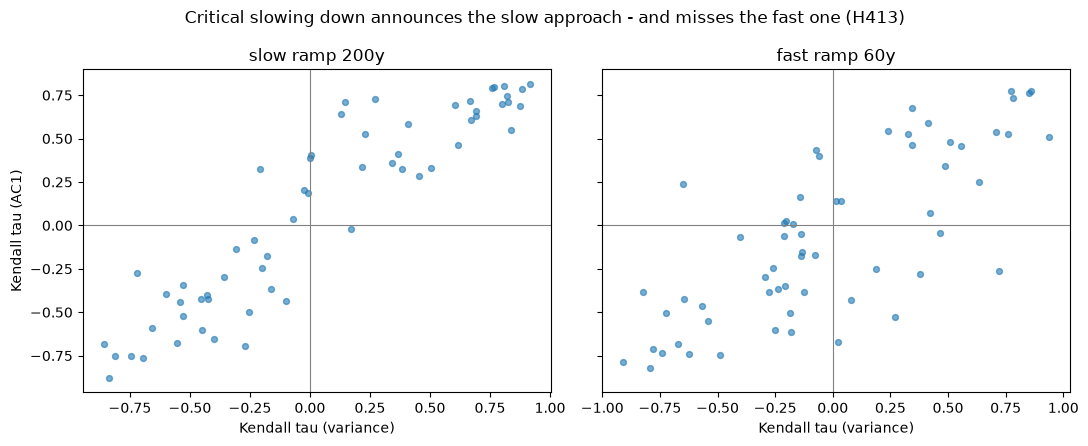

In [15]:
FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (tv, ta, ttl) in zip(axes, [(tv_s, ta_s, f"slow ramp {RAMP_SLOW}y"), (tv_f, ta_f, f"fast ramp {RAMP_FAST}y")]):
    ax.scatter(tv, ta, s=18, alpha=0.6)
    ax.axvline(0, color="grey", lw=0.8); ax.axhline(0, color="grey", lw=0.8)
    ax.set_xlabel("Kendall tau (variance)"); ax.set_title(ttl)
axes[0].set_ylabel("Kendall tau (AC1)")
fig.suptitle("Critical slowing down announces the slow approach - and misses the fast one (H413)")
fig.tight_layout(); fig.savefig(FIG / "nb40_csd_taus.png", dpi=130); plt.show()

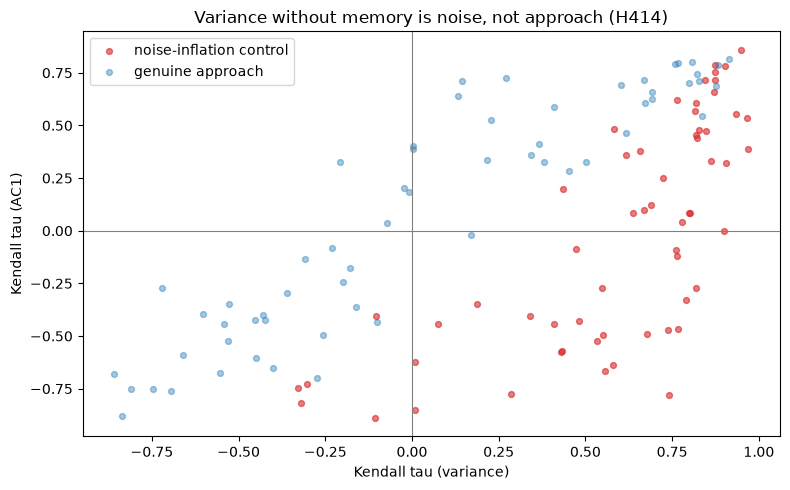

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(tvs, tas, s=18, alpha=0.6, color="#d62728", label="noise-inflation control")
ax.scatter(tv_s, ta_s, s=18, alpha=0.4, color="#1f77b4", label="genuine approach")
ax.axvline(0, color="grey", lw=0.8); ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Kendall tau (variance)"); ax.set_ylabel("Kendall tau (AC1)")
ax.set_title("Variance without memory is noise, not approach (H414)")
ax.legend(); fig.tight_layout(); fig.savefig(FIG / "nb40_discriminator.png", dpi=130); plt.show()

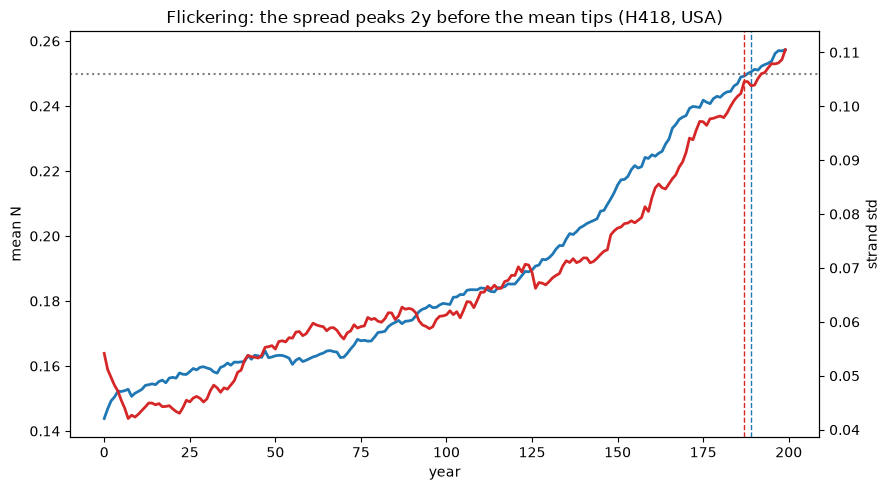

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
yrs_ax = np.arange(len(meanN))
ax.plot(yrs_ax, meanN, lw=2, color="#1f77b4", label="ensemble mean N")
ax2 = ax.twinx()
ax2.plot(yrs_ax, stdN, lw=2, color="#d62728", label="strand cross-sectional std")
ax.axhline(B_, color="grey", ls=":"); ax.axvline(cross, color="#1f77b4", ls="--", lw=1)
ax2.axvline(peak_std, color="#d62728", ls="--", lw=1)
ax.set_xlabel("year"); ax.set_ylabel("mean N"); ax2.set_ylabel("strand std")
ax.set_title(f"Flickering: the spread peaks {cross - peak_std}y before the mean tips (H418, USA)")
fig.tight_layout(); fig.savefig(FIG / "nb40_flickering.png", dpi=130); plt.show()

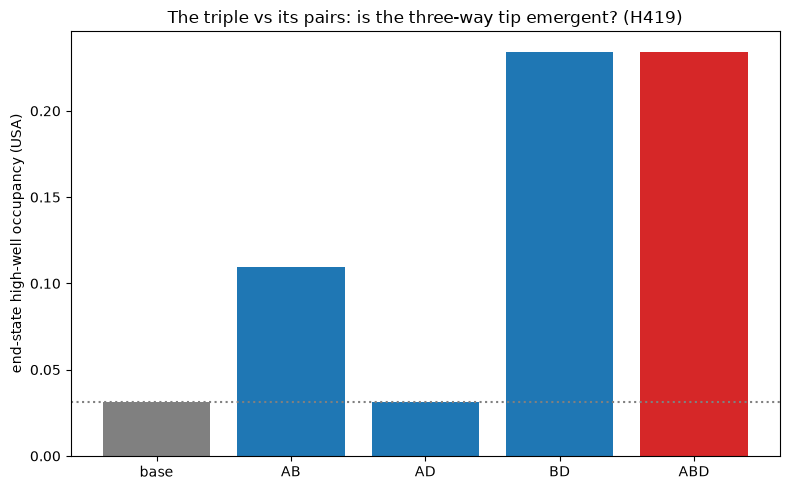

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["base", "AB", "AD", "BD", "ABD"]
ax.bar(labels, [occ_usa[k] for k in labels],
       color=["grey", "#1f77b4", "#1f77b4", "#1f77b4", "#d62728"])
ax.axhline(occ_usa["base"], color="grey", ls=":")
ax.set_ylabel("end-state high-well occupancy (USA)")
ax.set_title("The triple vs its pairs: is the three-way tip emergent? (H419)")
fig.tight_layout(); fig.savefig(FIG / "nb40_triple.png", dpi=130); plt.show()

## Save verdicts

In [19]:
out = dict(round="E44", hypotheses=VERDICTS,
           ews=dict(win_frac=WIN_FRAC, bw=BW, n_surr=N_SURR, n_seeds=N_SEEDS,
                    fold_in=FOLD_IN, eps0=EPS0,
                    h413=dict(slow=dict(tv=med(tv_s), ta=med(ta_s), sig=frac(sig_s)),
                              fast=dict(tv=med(tv_f), ta=med(ta_f), sig=frac(sig_f))),
                    h414=dict(tv=med(tvs), ta=med(tas)),
                    h415={f"w{wf}_b{bw}": list(v) for (wf, bw), v in ROB.items()},
                    h416=dict(lead200=float(np.median(l200)) if len(l200) else None,
                              lead100=float(np.median(l100)) if len(l100) else None,
                              nowarn200=nowarn200, nowarn100=nowarn100),
                    h417=dict(power=power, windows=tried)),
           h418=dict(cross_year=cross, std_peak_year=peak_std,
                     lead=int(cross - peak_std) if cross > 0 else None),
           h419=dict(usa={k: T3["USA"][k] for k in T3["USA"] if k != "I3_mid"},
                     korea={k: T3["Korea"][k] for k in T3["Korea"] if k != "I3_mid"},
                     I3_mid=T3["USA"]["I3_mid"], I3_mid_K128=float(I3_128), k_shift=float(kshift),
                     korea_occ_change=occ_kor_change, gwn_wire_alone=float(occ_gwn)),
           interaction_gate=GATE,
           equivalence=dict(nb38_germany_gated=asym_de, nb38_germany_linear=asym_lin))
Path("../reports").mkdir(exist_ok=True)
p = Path("../reports/nb40_e44_verdicts.json")
if p.exists():
    prev = json.load(open(p))
    for k in ("interaction_gate", "review"):
        if k in prev:
            out[k] = prev[k]
json.dump(out, open(p, "w"), indent=2)
rprint(f"[bold green]saved[/bold green] reports/nb40_e44_verdicts.json ({len(VERDICTS)} verdicts)")
for h, v in VERDICTS.items():
    rprint(f"  {h}: {v['verdict']}")

saved reports/nb40_e44_verdicts.json (7 verdicts)

H413: PARTIAL

H414: SUPPORTED

H415: PARTIAL

H416: PARTIAL

H417: REFUTED

H418: PARTIAL

H419: PARTIAL

## Conclusions

**Verdicts: 1 SUPPORTED / 5 PARTIAL / 1 REFUTED** (H414 supported; H413, H415, H416, H418,
H419 partial; H417 refuted). Campaign totals move to 419 hypotheses across 44 rounds.

**The early-warning story is honestly bleak - and that is the finding.** The critical-slowing-
down signature exists in the mathematical sense (under slow forcing the memory indicator's
ensemble tau rises, +0.24, while the variance tau stays flat at the anchored eps - and the one
clean SUPPORTED is the discriminator: a noisier society shows rising
variance with FLAT memory, tau_var +0.73 vs tau_AC1 +0.02, so the indicator pair does tell
drift from turbulence, H414). But per-trajectory detectability at the data-anchored noise is
weak: median joint significance 8% even under an ideal 200-year drift (H413 PARTIAL), the
signs survive only 6/9 analyst choices (H415 PARTIAL), and when warnings DO fire they lead by
a useful 42 years - but 66-85% of tips arrive with NO warning at all (H416 PARTIAL). The
operational question is adjudicated hard: at a realistic 40-year annual national series, joint
detection power is 1% - early warning at national scale is REFUTED (H417). A statistics
office watching one aggregate will not see this coming; monitoring needs subgroup dispersion
(the flickering lead in the coupled core is real but short, 2y, H418 PARTIAL), longer or
higher-frequency proxies, or pooling.

**The E42 triple residual closes with the gate's amendments (interaction-analyst: AMEND).**
There is NO emergent three-way basin event, and the null is STRUCTURAL: the norm channel
reads only fN, the education wave writes tempo, so the wave cannot reach the norm - the
pre-registration's causal story was mis-wired and is corrected in the record. The
noise-confirming runs uphold the null at the anchored and central eps (wave deltas exactly
0/64). What the corners actually found is the PAIR: broadcast x deterioration collide on the
W field (deterioration opens the misery gate the broadcast amplifies), tipping 15/64 USA
strands deterministically - and under anchored noise the same pair tips 35-41/64: fluctuations
AMPLIFY the two-way hazard the triple hypothesis was circling. The Korea occupancy control is
flagged vacuous (saturated at 64/64); the escape-metric re-read (0.000 movement) stands in.
The gWN=0.01 wire alone tips +1/64 (sub-threshold confirmed); corner B's solo tip was the
gWrv misery-gate wire.

**Method notes.** All eight corner runs are genuine coupled solves (no sums of solos);
inclusion-exclusion at K=64 with a 0.1% K=128 shift; the gate record is persisted under
`interaction_gate` in `reports/nb40_e44_verdicts.json` alongside the settling runs. The E42
interaction-gate residual list is now fully adjudicated - the third residual under the noise
regime E43 established, not merely deterministically.